In [1]:
import pandas as pd
df=pd.read_csv('/kaggle/input/dataset-sentiment-final-analysis/dataset_final_sentiment_balanced.csv')

In [2]:
display(df.columns)
print('='*80)
display(df.dtypes)
print('='*80)

Index(['review_id', 'app_name', 'category', 'username', 'rating',
       'text_original', 'timestamp', 'language', 'text_preprocessed',
       'meta_text_length', 'meta_emoji_count', 'meta_punctuation_count',
       'meta_uppercase_ratio', 'meta_sentence_count', 'meta_word_count',
       'meta_avg_word_length', 'score_grammar', 'score_length', 'score_emoji',
       'score_repetition', 'rule_score_final', 'lexicon_sentiment_polarity',
       'lexicon_sentiment_adjusted', 'lexicon_emotion',
       'lexicon_sarcasm_detected', 'lexicon_sarcasm_confidence',
       'stat_text_length', 'stat_word_count', 'stat_original_length',
       'stat_avg_word_length', 'stat_unique_word_ratio',
       'stat_punctuation_density', 'stat_emoji_density',
       'stat_uppercase_ratio', 'stat_sentence_count', 'stat_char_count',
       'stat_token_count', 'stat_unique_ratio', 'transformer_sentiment_label',
       'transformer_sentiment_score', 'transformer_confidence',
       'transformer_emb_mean', 'transform

review_id                       object
app_name                        object
category                        object
username                        object
rating                           int64
text_original                   object
timestamp                       object
language                        object
text_preprocessed               object
meta_text_length                 int64
meta_emoji_count                 int64
meta_punctuation_count           int64
meta_uppercase_ratio           float64
meta_sentence_count              int64
meta_word_count                  int64
meta_avg_word_length           float64
score_grammar                  float64
score_length                   float64
score_emoji                    float64
score_repetition               float64
rule_score_final               float64
lexicon_sentiment_polarity     float64
lexicon_sentiment_adjusted     float64
lexicon_emotion                 object
lexicon_sarcasm_detected          bool
lexicon_sarcasm_confidenc

In [3]:
# Columns to exclude
exclude_cols = ['text_preprocessed','text_original','timestamp', 'review_id', 'username']

# Select object type columns except excluded ones
obj_cols = [col for col in df.select_dtypes(include='object').columns if col not in exclude_cols]

# Print value counts for each object column
for col in obj_cols:
    print(f"\n📊 Column: {col}")
    print(df[col].value_counts(dropna=False))


📊 Column: app_name
app_name
Amazon       1490
Netflix      1466
Spotify      1446
Daraz        1440
Instagram    1385
Foodpanda    1366
WhatsApp     1354
Careem       1289
Easypaisa    1234
JazzCash     1089
Name: count, dtype: int64

📊 Column: category
category
E-commerce       2930
Entertainment    2912
Social Media     2739
Food Delivery    2655
Banking          2323
Name: count, dtype: int64

📊 Column: language
language
roman_urdu    6399
en            4240
mixed         2788
unknown         92
ur              40
Name: count, dtype: int64

📊 Column: lexicon_emotion
lexicon_emotion
neutral     13227
joy           184
sadness        91
surprise       34
anger          16
fear            7
Name: count, dtype: int64

📊 Column: transformer_sentiment_label
transformer_sentiment_label
positive    13506
neutral        53
Name: count, dtype: int64

📊 Column: emotion_final
emotion_final
joy         13353
anger          89
sadness        70
neutral        46
surprise        1
Name: count, dt

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


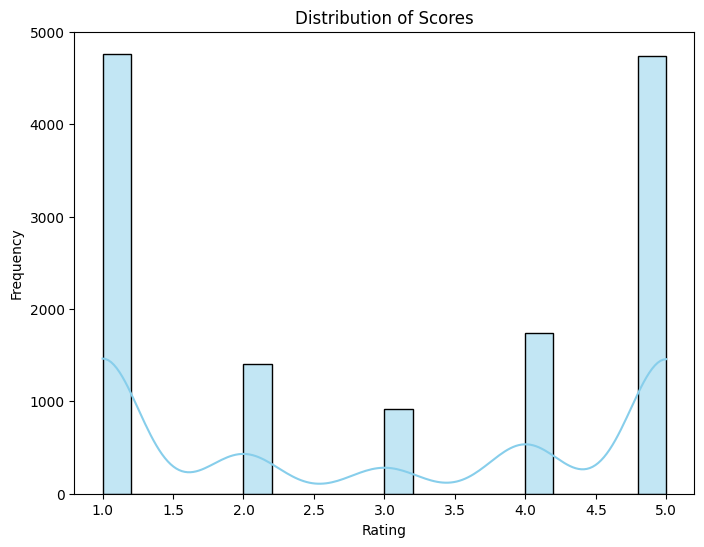

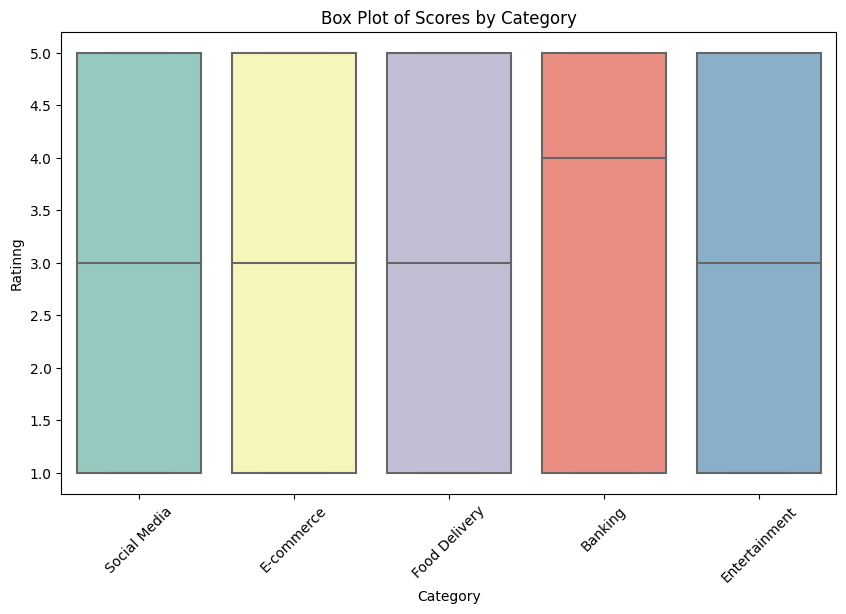

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

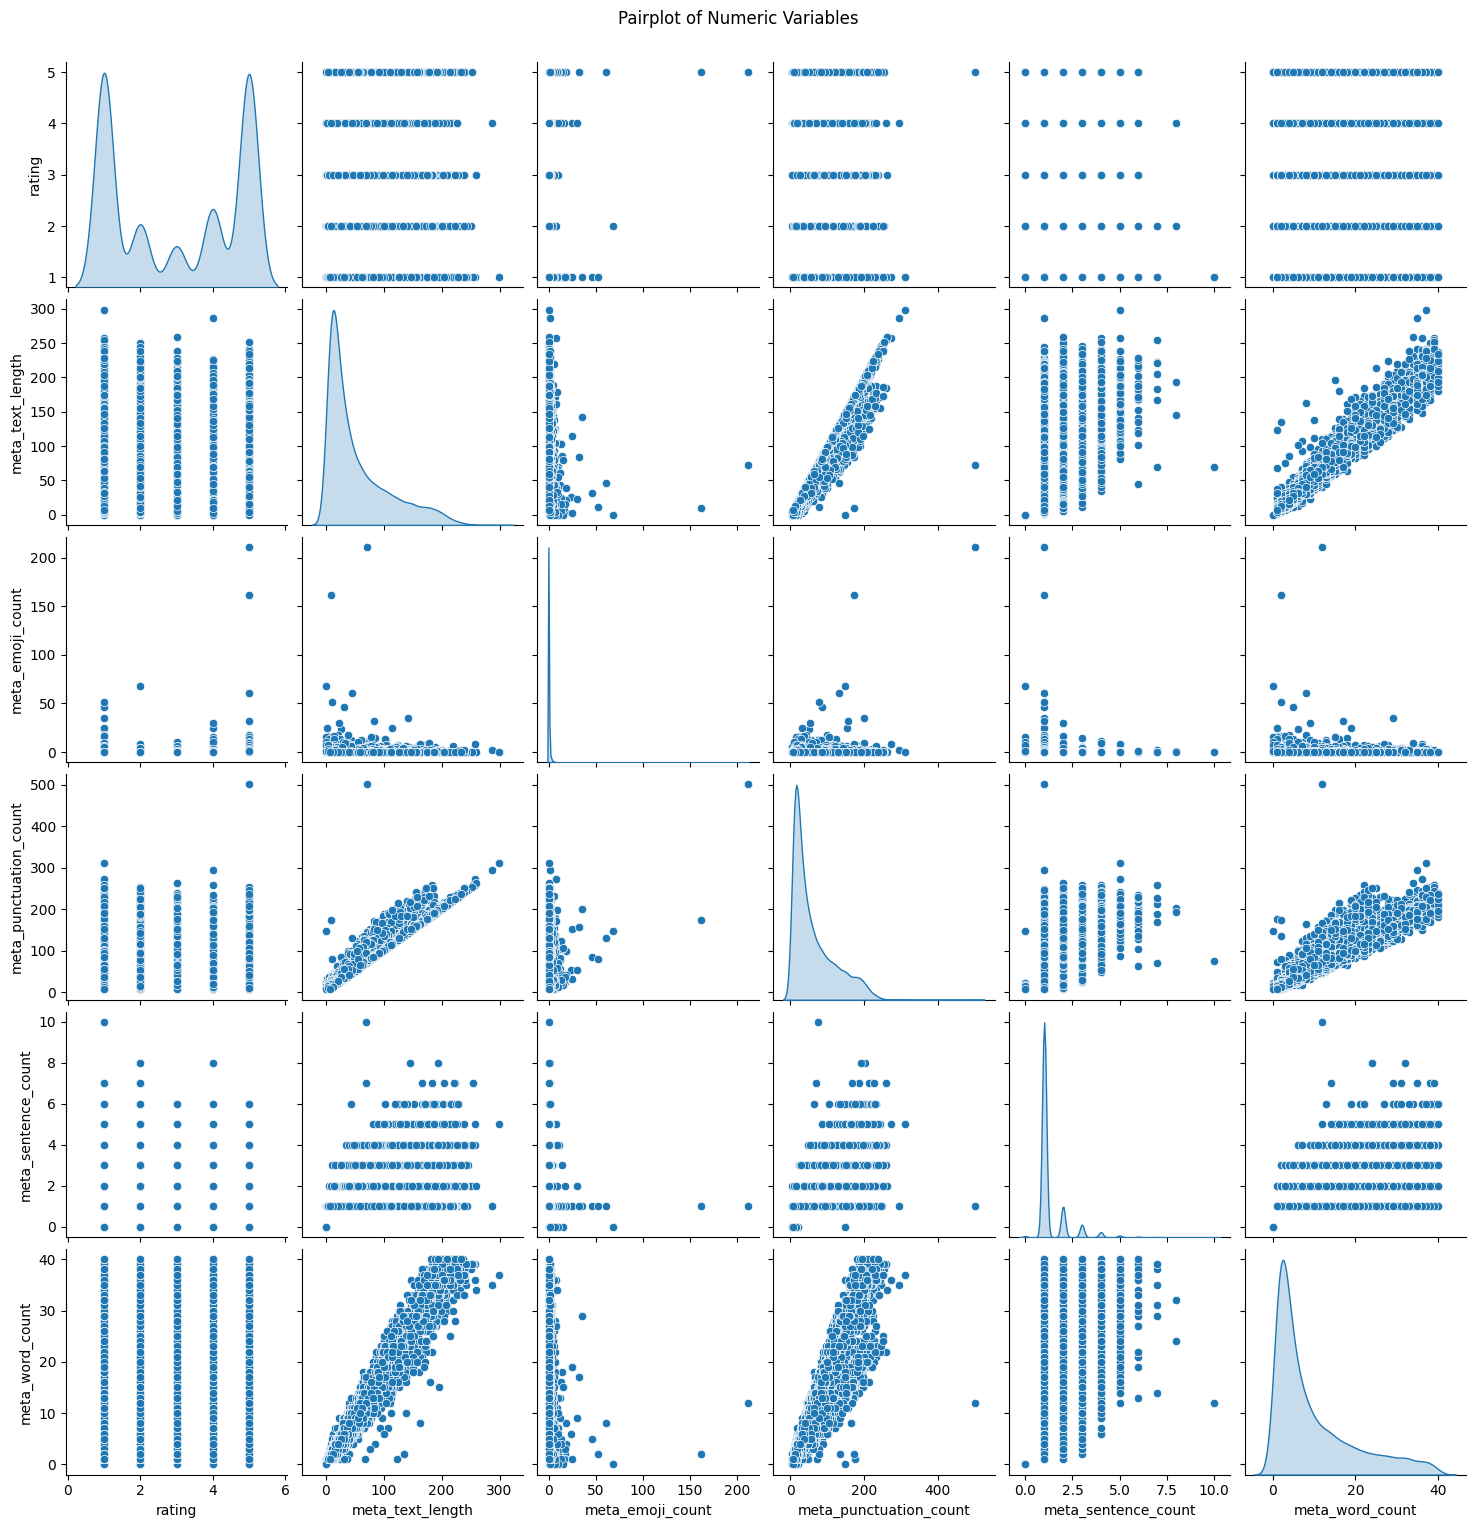

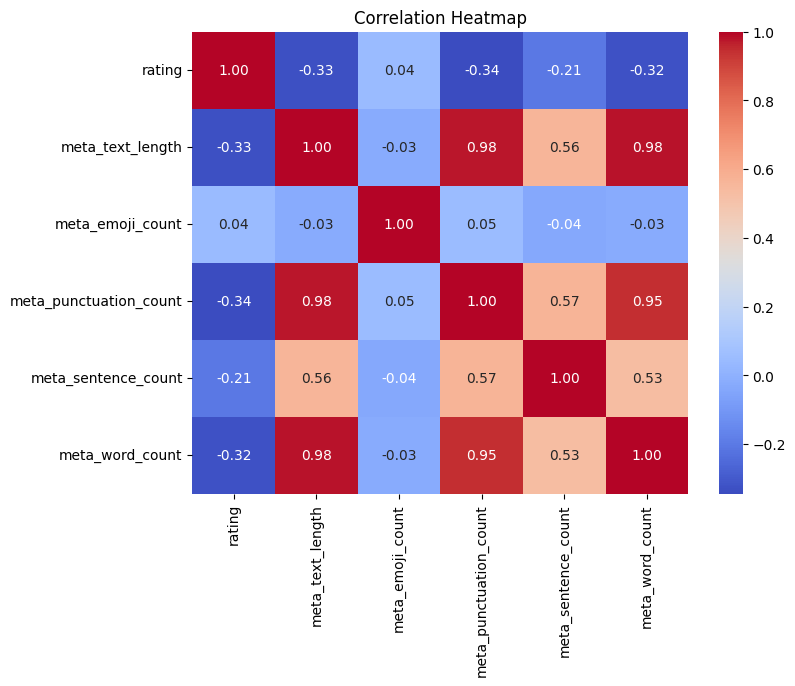

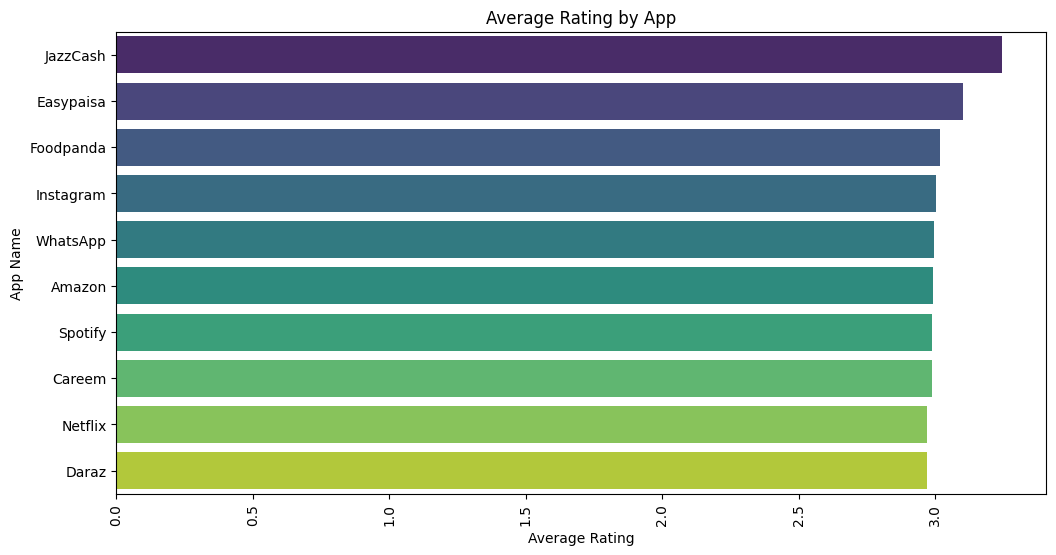

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Visualization 1: Histogram of Scores
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Scores')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Box Plot of Scores by Category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='rating', palette='Set3')
plt.title('Box Plot of Scores by Category')
plt.xlabel('Category')
plt.ylabel('Ratinng')
plt.xticks(rotation=45)
plt.show()

# Visualization 3: Pairplot of Numeric Variables
numeric_columns = df.select_dtypes(include=['int64']).columns
sns.pairplot(data=df[numeric_columns], diag_kind='kde')
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()

# Visualization 4: Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Visualization 5: Bar Plot of Average Scores by App
app_avg_scores = df.groupby('app_name')['rating'].mean().reset_index()
app_avg_scores = app_avg_scores.sort_values(by='rating', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=app_avg_scores, x='rating', y='app_name', palette='viridis')
plt.title('Average Rating by App')
plt.xlabel('Average Rating')
plt.ylabel('App Name')
plt.xticks(rotation=90)
plt.show()

In [5]:
import pandas as pd
import spacy
import re

nlp = spacy.load("en_core_web_sm")

# -------------------------
# Safe Clean Function
# -------------------------
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)

    text = re.sub(r"\W", " ", text)
    text = text.lower()
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# -------------------------
# Full Preprocess Function
# -------------------------
def preprocess_text(text):
    text = clean_text(text)
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha
    ]
    return " ".join(tokens)

# -------------------------
# Apply on your column
# -------------------------
df["cleaned_content"] = (
    df["text_preprocessed"]
    .astype(str)
    .fillna("")
    .apply(preprocess_text)
)

df.head()


,review_id,app_name,category,username,rating,text_original,timestamp,language,text_preprocessed,meta_text_length,...,sarcasm_confidence,sarcasm_emoji_mismatch,sentiment_final,sentiment_score,sentiment_confidence,sentiment_emotion,sentiment_sarcasm_applied,sentiment_before_boost,sentiment_after_boost,cleaned_content
0,91297a5e-4b89-41fe-a356-525a772c5b58,WhatsApp,Social Media,লিপি রানী বনিক সংগীত শিল্পী,2,hey I can't using this app.please help me.I do...,2025-11-07 13:46:34,roman_urdu,hey i can't using this app.please help me.i do...,94,...,0.0,False,negative,0.109402,0.027706,joy,False,0.121558,0.109402,hey app help don want update app stop
1,b6842d3f-695e-4779-8a8a-afa61f8d3569,WhatsApp,Social Media,Dusmanta Polei,2,why individual call ringtone has not set. plea...,2025-11-07 13:50:58,roman_urdu,why individual call ringtone has not set. plea...,61,...,0.0,False,negative,0.073464,0.012493,joy,False,0.081626,0.073464,individual ringtone set update
2,09fb44e6-7f69-4314-ba6c-1f4fdc696008,WhatsApp,Social Media,Vk Singh,2,nice 👍,2025-11-07 14:29:04,mixed,nice,4,...,0.0,False,positive,0.478490,0.354044,joy,False,0.357159,0.478490,nice
3,d18b6be3-1698-4e14-a156-9081397289f7,WhatsApp,Social Media,Rupali Kashyap,2,whatsapp par offline hote hue bi online dhika ...,2025-11-07 14:30:04,roman_urdu,whatsapp offline hote hue bi online dhika raha...,68,...,0.0,False,negative,0.112864,0.029487,joy,False,0.125404,0.112864,whatsapp offline hote hue bi online dhika raha...
4,b1d6e961-6f33-40f8-b408-076445859ff7,WhatsApp,Social Media,Neha Patil,2,bio is not permanent,2025-11-07 14:30:43,mixed,bio permanent,13,...,0.0,False,neutral,0.125661,0.036553,joy,False,0.139624,0.125661,bio permanent


In [6]:
# ========================================
# Feature Selection
# ========================================
features = [
    'transformer_sentiment_score',
    'transformer_confidence',
    'transformer_emb_mean',
    'transformer_emb_std',
    'lexicon_sentiment_polarity',
    'lexicon_sentiment_adjusted',
    'lexicon_sarcasm_confidence',
    'emotion_confidence',
    'sarcasm_detected',
    'sarcasm_confidence',
    'meta_text_length',
    'meta_word_count',
    'meta_emoji_count',
    'meta_uppercase_ratio',
    'rule_score_final',
    'score_repetition',
    'stat_unique_word_ratio',
    'stat_punctuation_density',
    'rating'
]

label = 'sentiment_final'


In [7]:
from sklearn.preprocessing import LabelEncoder
# ========================================
# Label Encoding for XGBoost
# ========================================
y = df['sentiment_final']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"✅ Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"   {label} -> {i}")


print(f"✅ y shape: {y.shape}")
print(f"✅ Classes: {le.classes_}\n")

✅ Label mapping:
   negative -> 0
   neutral -> 1
   positive -> 2
✅ y shape: (13559,)
✅ Classes: ['negative' 'neutral' 'positive']



In [8]:
import pandas as pd

# Target column
target = 'rating'

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation with target
correlation_with_target = df[numeric_cols].corr()[target].sort_values(ascending=False)

# Show correlation values
print("📊 Correlation of numeric features with rating:")
print(correlation_with_target.head(20))


📊 Correlation of numeric features with rating:
rating                         1.000000
sentiment_before_boost         0.901210
sentiment_score                0.793423
sentiment_after_boost          0.793423
sentiment_confidence           0.609735
lexicon_sentiment_adjusted     0.476549
lexicon_sentiment_polarity     0.476176
emotion_confidence             0.291117
rule_score_final               0.231558
score_length                   0.219825
score_emoji                    0.161221
stat_emoji_density             0.132389
transformer_confidence         0.043858
meta_emoji_count               0.042661
transformer_emb_std            0.032920
transformer_sentiment_score    0.024738
stat_uppercase_ratio           0.021581
meta_uppercase_ratio           0.021581
score_repetition               0.012728
lexicon_sarcasm_confidence     0.008388
Name: rating, dtype: float64


In [9]:
import numpy as np

X_rat=df['cleaned_content']

print('='*60)

rat = np.where(df['rating'] >= 4, 
                                2,          # positive
                                np.where(df['rating'] == 3,
                                         1,  # neutral
                                         0)) # negative

display(type(rat))

print('='*60)

from sklearn.model_selection import train_test_split

X_train_rat, X_test_rat, y_train_rat, y_test_rat = train_test_split(X_rat, rat, test_size=0.2, random_state=42)


numpy.ndarray

In [10]:
import pandas as pd

# Target column
y = y_encoded 

# Only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation with y_encoded
correlation_with_target = df[numeric_cols].corrwith(pd.Series(y)).sort_values(ascending=False)

print("📊 Correlation of numeric features with Sentiment Final:")
print(correlation_with_target.head(20))


📊 Correlation of numeric features with Sentiment Final:
sentiment_before_boost         0.883558
rating                         0.860587
sentiment_score                0.809063
sentiment_after_boost          0.809063
sentiment_confidence           0.582517
lexicon_sentiment_adjusted     0.538613
lexicon_sentiment_polarity     0.538107
emotion_confidence             0.328974
rule_score_final               0.223267
score_length                   0.213458
transformer_sentiment_score    0.177285
score_emoji                    0.152368
transformer_confidence         0.141508
stat_emoji_density             0.121284
transformer_emb_max            0.064903
transformer_emb_min            0.045201
meta_emoji_count               0.031215
score_repetition               0.017041
meta_uppercase_ratio           0.013652
stat_uppercase_ratio           0.013652
dtype: float64


/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# TF-IDF

In [11]:
import numpy as np
from scipy.sparse import load_npz, hstack
from sklearn.model_selection import train_test_split, cross_val_score
# ========================================
# Data Preparation
# ========================================
print("🔄 Preparing data...")
df['sarcasm_detected'] = df['sarcasm_detected'].astype(int)

X_dense = df[features].copy()

for col in X_dense.columns:
    if X_dense[col].dtype == 'object' or X_dense[col].dtype == 'bool':
        X_dense[col] = pd.to_numeric(X_dense[col], errors='coerce')

X_dense = X_dense.fillna(0).astype(np.float64).values

X_tfidf = load_npz('/kaggle/input/dataset-sentiment-final-analysis/tfidf_features.npz')
X_combined = hstack([X_dense, X_tfidf])
print(f"\n✅ X_combined shape: {X_combined.shape}")
print(f"\n✅ X_combined shape: {y_encoded.shape}")


# ========================================
# Train-Test Split
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Convert back to original labels for display
y_test_labels = le.inverse_transform(y_test)

print(f"✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size: {X_test.shape[0]}\n")
print("="*60)


🔄 Preparing data...

✅ X_combined shape: (13559, 5019)

✅ X_combined shape: (13559,)
✅ Train size: 10847
✅ Test size: 2712



In [12]:
from scipy.sparse import load_npz, hstack
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ========================================
# Classifiers with Regularization (Anti-Overfitting)
# ========================================
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, 
        C=0.1,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=10),
    'Gradient Boosting': GradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.1,
        n_estimators=100,
        min_samples_split=20,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        random_state=42
    ),
}

# ========================================
# Training & Evaluation with Cross-Validation
# ========================================
results = []

for name, classifier in classifiers.items():
    print(f"\n🔄 Training: {name}...")
    
    try:
        if name == 'Gaussian Naive Bayes':
            X_train_dense = X_train.toarray()
            X_test_dense = X_test.toarray()
            cv_scores = cross_val_score(classifier, X_train_dense, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train_dense, y_train)
            y_pred = classifier.predict(X_test_dense)
        else:
            cv_scores = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
        
        y_pred_labels = le.inverse_transform(y_pred)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        overfitting_gap = accuracy - cv_mean
        
        results.append({
            'Classifier': name,
            'Test Accuracy': accuracy,
            'CV F1-Score': cv_mean,
            'CV Std': cv_std,
            'Overfitting Gap': overfitting_gap,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"✅ {name} - Completed!")
        print(f"   Test Accuracy:    {accuracy:.4f}")
        print(f"   CV F1-Score:      {cv_mean:.4f} (±{cv_std:.4f})")
        print(f"   Overfitting Gap:  {overfitting_gap:.4f} {'⚠️ HIGH!' if overfitting_gap > 0.1 else '✅ OK'}")
        print(f"   Precision:        {precision:.4f}")
        print(f"   Recall:           {recall:.4f}")
        print(f"   F1-Score:         {f1:.4f}")
        
        print(f"\n📊 Classification Report:")
        print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
        
        print(f"\n📊 Confusion Matrix:")
        cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
        cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
        print(cm_df)
        print("="*80)
        
    except Exception as e:
        print(f"❌ Error in {name}: {str(e)}")
        print("="*80)
        continue

# ========================================
# Find and Save Best Model by Test Accuracy
# ========================================
import joblib
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['Test Accuracy'].idxmax()]
best_model_name = best_row['Classifier']
best_model = classifiers[best_model_name]

print("\n🏆 BEST MODEL SELECTED")
print("Model:", best_model_name)
print("Accuracy:", best_row['Test Accuracy'])

joblib.dump(best_model, "best_model_tfidf.pkl")
print("\n💾 Saved: best_model_tfidf.pkl")



🔄 Training: Logistic Regression...
✅ Logistic Regression - Completed!
   Test Accuracy:    0.8698
   CV F1-Score:      0.8500 (±0.0035)
   Overfitting Gap:  0.0198 ✅ OK
   Precision:        0.8616
   Recall:           0.8698
   F1-Score:         0.8559

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.93      0.86       840
     neutral       0.74      0.42      0.53       481
    positive       0.94      0.99      0.97      1391

    accuracy                           0.87      2712
   macro avg       0.83      0.78      0.79      2712
weighted avg       0.86      0.87      0.86      2712


📊 Confusion Matrix:
          negative  neutral  positive
negative       779       59         2
neutral        197      201        83
positive         1       11      1379

🔄 Training: Decision Tree...
✅ Decision Tree - Completed!
   Test Accuracy:    0.9875
   CV F1-Score:      0.9876 (±0.0035)
   Overfitting Gap:  -0.0001 ✅ OK
   Prec

In [13]:
# ========================================
# Results Summary
# ========================================
print("\n\n📊 FINAL RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print(results_df.to_string(index=False))
print("="*80)

# Find best model (lowest overfitting gap + highest F1)
results_df['Score'] = results_df['F1-Score'] - results_df['Overfitting Gap']
best_model_idx = results_df['Score'].idxmax()

print(f"\n🏆 Best Model (Balanced): {results_df.loc[best_model_idx, 'Classifier']}")
print(f"   Test F1-Score:    {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
print(f"   CV F1-Score:      {results_df.loc[best_model_idx, 'CV F1-Score']:.4f}")
print(f"   Overfitting Gap:  {results_df.loc[best_model_idx, 'Overfitting Gap']:.4f}")

print("\n⚠️  Models with Overfitting (Gap > 0.10):")
overfitted = results_df[results_df['Overfitting Gap'] > 0.10]
if len(overfitted) > 0:
    print(overfitted[['Classifier', 'Test Accuracy', 'CV F1-Score', 'Overfitting Gap']])
else:
    print("   None - All models are well-generalized! ✅")



📊 FINAL RESULTS SUMMARY
          Classifier  Test Accuracy  CV F1-Score   CV Std  Overfitting Gap  Precision   Recall  F1-Score
             XGBoost       0.993732     0.990590 0.000904         0.003141   0.993720 0.993732  0.993717
   Gradient Boosting       0.991150     0.988489 0.001037         0.002661   0.991183 0.991150  0.991160
       Decision Tree       0.987463     0.987564 0.003531        -0.000101   0.987423 0.987463  0.987431
 Logistic Regression       0.869838     0.849991 0.003453         0.019847   0.861637 0.869838  0.855876
 K-Nearest Neighbors       0.823009     0.808610 0.003469         0.014399   0.812993 0.823009  0.809706
                 SVM       0.797935     0.724782 0.002627         0.073153   0.677192 0.797935  0.726928
       Random Forest       0.770280     0.738279 0.026859         0.032001   0.803934 0.770280  0.704522
Gaussian Naive Bayes       0.641962     0.645189 0.004292        -0.003227   0.664366 0.641962  0.651385

🏆 Best Model (Balanced): XGB

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, save_npz, load_npz
import pickle
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,4), max_features=10000,)


# Fit and transform on the training data for TF-IDF
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_rat)

# Transform the testing data for TF-IDF
X_test_tfidf = tfidf_vectorizer.transform(X_test_rat)

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier  # Import Gradient Boosting Classifier

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    
}

# Train and evaluate classifiers
for name, classifier in classifiers.items():
    classifier_pipeline = make_pipeline(classifier)
    
    if name == 'Gaussian Naive Bayes':
        # Convert sparse matrices to dense arrays
        X_train_dense = X_train_tfidf.toarray()
        X_test_dense = X_test_tfidf.toarray()
        classifier_pipeline.fit(X_train_dense, y_train_rat)  # No label encoding here
        y_pred = classifier_pipeline.predict(X_test_dense)
    else:
        classifier_pipeline.fit(X_train_tfidf, y_train_rat)  # No label encoding here
        y_pred = classifier_pipeline.predict(X_test_tfidf)
    
    accuracy = accuracy_score(y_test_rat, y_pred)
    precision = precision_score(y_test_rat,  y_pred, average='weighted')
    recall = recall_score(y_test_rat,  y_pred, average='weighted')
    f1 = f1_score(y_test_rat,  y_pred, average='weighted')
    
    print(f"Classifier: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print()

    classification_rep = classification_report(y_test_rat, y_pred)  # No target_names parameter
    print("Classification Report:")
    print(classification_rep)
    print("="*70)

Classifier: Logistic Regression
Accuracy: 0.79
Precision: 0.74
Recall: 0.79
F1-Score: 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1227
           1       0.00      0.00      0.00       177
           2       0.81      0.83      0.82      1308

    accuracy                           0.79      2712
   macro avg       0.52      0.56      0.54      2712
weighted avg       0.74      0.79      0.76      2712

Classifier: Decision Tree
Accuracy: 0.71
Precision: 0.69
Recall: 0.71
F1-Score: 0.70

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73      1227
           1       0.07      0.05      0.06       177
           2       0.73      0.79      0.76      1308

    accuracy                           0.71      2712
   macro avg       0.52      0.52      0.51      2712
weighted avg       0.69      0.71      0.70      2712

Classifier: Ra

# BoW

In [16]:

X_bow = load_npz('/kaggle/input/dataset-sentiment-final-analysis/bow_features.npz')
X_combined = hstack([X_dense, X_bow])
print(f"\n✅ X_combined shape: {X_combined.shape}")
print(f"\n✅ X_combined shape: {y_encoded.shape}")


# ========================================
# Train-Test Split
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Convert back to original labels for display
y_test_labels = le.inverse_transform(y_test)

print(f"✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size: {X_test.shape[0]}\n")
print("="*60)


✅ X_combined shape: (13559, 5019)

✅ X_combined shape: (13559,)
✅ Train size: 10847
✅ Test size: 2712



In [17]:
from scipy.sparse import load_npz, hstack
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ========================================
# Classifiers with Regularization (Anti-Overfitting)
# ========================================
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, 
        C=0.1,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=10),
    'Gradient Boosting': GradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.1,
        n_estimators=100,
        min_samples_split=20,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        random_state=42
    ),
}

# ========================================
# Training & Evaluation with Cross-Validation
# ========================================
results = []

for name, classifier in classifiers.items():
    print(f"\n🔄 Training: {name}...")
    
    try:
        if name == 'Gaussian Naive Bayes':
            X_train_dense = X_train.toarray()
            X_test_dense = X_test.toarray()
            cv_scores = cross_val_score(classifier, X_train_dense, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train_dense, y_train)
            y_pred = classifier.predict(X_test_dense)
        else:
            cv_scores = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
        
        y_pred_labels = le.inverse_transform(y_pred)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        overfitting_gap = accuracy - cv_mean
        
        results.append({
            'Classifier': name,
            'Test Accuracy': accuracy,
            'CV F1-Score': cv_mean,
            'CV Std': cv_std,
            'Overfitting Gap': overfitting_gap,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"✅ {name} - Completed!")
        print(f"   Test Accuracy:    {accuracy:.4f}")
        print(f"   CV F1-Score:      {cv_mean:.4f} (±{cv_std:.4f})")
        print(f"   Overfitting Gap:  {overfitting_gap:.4f} {'⚠️ HIGH!' if overfitting_gap > 0.1 else '✅ OK'}")
        print(f"   Precision:        {precision:.4f}")
        print(f"   Recall:           {recall:.4f}")
        print(f"   F1-Score:         {f1:.4f}")
        
        print(f"\n📊 Classification Report:")
        print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
        
        print(f"\n📊 Confusion Matrix:")
        cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
        cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
        print(cm_df)
        print("="*80)
        
    except Exception as e:
        print(f"❌ Error in {name}: {str(e)}")
        print("="*80)
        continue

# ========================================
# Find and Save Best Model by Test Accuracy
# ========================================
import joblib
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['Test Accuracy'].idxmax()]
best_model_name = best_row['Classifier']
best_model = classifiers[best_model_name]

print("\n🏆 BEST MODEL SELECTED")
print("Model:", best_model_name)
print("Accuracy:", best_row['Test Accuracy'])

joblib.dump(best_model, "best_model_bag.pkl")
print("\n💾 Saved: best_model_bag.pkl")



🔄 Training: Logistic Regression...
✅ Logistic Regression - Completed!
   Test Accuracy:    0.8617
   CV F1-Score:      0.8508 (±0.0059)
   Overfitting Gap:  0.0109 ✅ OK
   Precision:        0.8525
   Recall:           0.8617
   F1-Score:         0.8545

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.88      0.85       840
     neutral       0.65      0.49      0.56       481
    positive       0.95      0.98      0.96      1391

    accuracy                           0.86      2712
   macro avg       0.80      0.78      0.79      2712
weighted avg       0.85      0.86      0.85      2712


📊 Confusion Matrix:
          negative  neutral  positive
negative       742       97         1
neutral        169      236        76
positive         4       28      1359

🔄 Training: Decision Tree...
✅ Decision Tree - Completed!
   Test Accuracy:    0.9875
   CV F1-Score:      0.9880 (±0.0031)
   Overfitting Gap:  -0.0006 ✅ OK
   Prec

In [18]:
# ========================================
# Results Summary
# ========================================
print("\n\n📊 FINAL RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print(results_df.to_string(index=False))
print("="*80)

# Find best model (lowest overfitting gap + highest F1)
results_df['Score'] = results_df['F1-Score'] - results_df['Overfitting Gap']
best_model_idx = results_df['Score'].idxmax()

print(f"\n🏆 Best Model (Balanced): {results_df.loc[best_model_idx, 'Classifier']}")
print(f"   Test F1-Score:    {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
print(f"   CV F1-Score:      {results_df.loc[best_model_idx, 'CV F1-Score']:.4f}")
print(f"   Overfitting Gap:  {results_df.loc[best_model_idx, 'Overfitting Gap']:.4f}")

print("\n⚠️  Models with Overfitting (Gap > 0.10):")
overfitted = results_df[results_df['Overfitting Gap'] > 0.10]
if len(overfitted) > 0:
    print(overfitted[['Classifier', 'Test Accuracy', 'CV F1-Score', 'Overfitting Gap']])
else:
    print("   None - All models are well-generalized! ✅")



📊 FINAL RESULTS SUMMARY
          Classifier  Test Accuracy  CV F1-Score   CV Std  Overfitting Gap  Precision   Recall  F1-Score
             XGBoost       0.992625     0.990312 0.000774         0.002313   0.992613 0.992625  0.992617
   Gradient Boosting       0.991888     0.989315 0.000977         0.002572   0.991944 0.991888  0.991902
       Decision Tree       0.987463     0.988022 0.003067        -0.000559   0.987423 0.987463  0.987431
 Logistic Regression       0.861726     0.850787 0.005939         0.010939   0.852523 0.861726  0.854459
 K-Nearest Neighbors       0.796460     0.791735 0.004088         0.004726   0.790798 0.796460  0.790311
       Random Forest       0.786136     0.702902 0.031931         0.083234   0.816176 0.786136  0.736912
                 SVM       0.798304     0.724597 0.002937         0.073707   0.677548 0.798304  0.727290
Gaussian Naive Bayes       0.616519     0.621461 0.010203        -0.004942   0.639698 0.616519  0.621926

🏆 Best Model (Balanced): XGB

In [19]:
# Create BoW vectorizer
bow_vectorizer = CountVectorizer(ngram_range=(1,4), max_features=6000, stop_words='english')  # You can adjust the number of features as needed
# Fit and transform on the training data for BoW
X_train_bow = bow_vectorizer.fit_transform(X_train_rat)

# Transform the testing data for BoW
X_test_bow = bow_vectorizer.transform(X_test_rat)

In [20]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier  # Import Gradient Boosting Classifier

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    
}

# Train and evaluate classifiers
for name, classifier in classifiers.items():
    classifier_pipeline = make_pipeline(classifier)
    
    if name == 'Gaussian Naive Bayes':
        # Convert sparse matrices to dense arrays
        X_train_dense = X_train_bow.toarray()
        X_test_dense = X_test_bow.toarray()
        classifier_pipeline.fit(X_train_dense, y_train_rat)  # No label encoding here
        y_pred = classifier_pipeline.predict(X_test_dense)
    else:
        # Use X_test_bow for testing in the else branch
        classifier_pipeline.fit(X_train_bow, y_train_rat)  # No label encoding here
        y_pred = classifier_pipeline.predict(X_test_bow)
    
    accuracy = accuracy_score(y_test_rat, y_pred)
    precision = precision_score(y_test_rat,  y_pred, average='weighted')
    recall = recall_score(y_test_rat,  y_pred, average='weighted')
    f1 = f1_score(y_test_rat,  y_pred, average='weighted')
    
    print(f"Classifier: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print()

    classification_rep = classification_report(y_test_rat, y_pred)  # No target_names parameter
    print("Classification Report:")
    print(classification_rep)
    print("="*70)

Classifier: Logistic Regression
Accuracy: 0.77
Precision: 0.73
Recall: 0.77
F1-Score: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78      1227
           1       0.08      0.01      0.02       177
           2       0.77      0.85      0.81      1308

    accuracy                           0.77      2712
   macro avg       0.54      0.55      0.54      2712
weighted avg       0.73      0.77      0.75      2712

Classifier: Decision Tree
Accuracy: 0.72
Precision: 0.70
Recall: 0.72
F1-Score: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      1227
           1       0.12      0.07      0.09       177
           2       0.74      0.80      0.76      1308

    accuracy                           0.72      2712
   macro avg       0.54      0.53      0.53      2712
weighted avg       0.70      0.72      0.71      2712

Classifier: Ra

# TF-IDF and BoW

In [21]:

X_com = load_npz('/kaggle/input/dataset-sentiment-final-analysis/combined_features.npz')
X_combined = hstack([X_dense, X_com])
print(f"\n✅ X_combined shape: {X_combined.shape}")
print(f"\n✅ X_combined shape: {y_encoded.shape}")


# ========================================
# Train-Test Split
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Convert back to original labels for display
y_test_labels = le.inverse_transform(y_test)

print(f"✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size: {X_test.shape[0]}\n")
print("="*60)



✅ X_combined shape: (13559, 10019)

✅ X_combined shape: (13559,)
✅ Train size: 10847
✅ Test size: 2712



In [22]:
from scipy.sparse import load_npz, hstack
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ========================================
# Classifiers with Regularization (Anti-Overfitting)
# ========================================
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, 
        C=0.1,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=10),
    'Gradient Boosting': GradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.1,
        n_estimators=100,
        min_samples_split=20,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        random_state=42
    ),
}

# ========================================
# Training & Evaluation with Cross-Validation
# ========================================
results = []

for name, classifier in classifiers.items():
    print(f"\n🔄 Training: {name}...")
    
    try:
        if name == 'Gaussian Naive Bayes':
            X_train_dense = X_train.toarray()
            X_test_dense = X_test.toarray()
            cv_scores = cross_val_score(classifier, X_train_dense, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train_dense, y_train)
            y_pred = classifier.predict(X_test_dense)
        else:
            cv_scores = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1_weighted')
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
        
        y_pred_labels = le.inverse_transform(y_pred)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        overfitting_gap = accuracy - cv_mean
        
        results.append({
            'Classifier': name,
            'Test Accuracy': accuracy,
            'CV F1-Score': cv_mean,
            'CV Std': cv_std,
            'Overfitting Gap': overfitting_gap,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"✅ {name} - Completed!")
        print(f"   Test Accuracy:    {accuracy:.4f}")
        print(f"   CV F1-Score:      {cv_mean:.4f} (±{cv_std:.4f})")
        print(f"   Overfitting Gap:  {overfitting_gap:.4f} {'⚠️ HIGH!' if overfitting_gap > 0.1 else '✅ OK'}")
        print(f"   Precision:        {precision:.4f}")
        print(f"   Recall:           {recall:.4f}")
        print(f"   F1-Score:         {f1:.4f}")
        
        print(f"\n📊 Classification Report:")
        print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
        
        print(f"\n📊 Confusion Matrix:")
        cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
        cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
        print(cm_df)
        print("="*80)
        
    except Exception as e:
        print(f"❌ Error in {name}: {str(e)}")
        print("="*80)
        continue

# ========================================
# Find and Save Best Model by Test Accuracy
# ========================================
import joblib
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['Test Accuracy'].idxmax()]
best_model_name = best_row['Classifier']
best_model = classifiers[best_model_name]

print("\n🏆 BEST MODEL SELECTED")
print("Model:", best_model_name)
print("Accuracy:", best_row['Test Accuracy'])

joblib.dump(best_model, "best_model_combine.pkl")
print("\n💾 Saved: best_model_combine.pkl")



🔄 Training: Logistic Regression...
✅ Logistic Regression - Completed!
   Test Accuracy:    0.8617
   CV F1-Score:      0.8505 (±0.0059)
   Overfitting Gap:  0.0113 ✅ OK
   Precision:        0.8529
   Recall:           0.8617
   F1-Score:         0.8549

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.88      0.85       840
     neutral       0.65      0.50      0.56       481
    positive       0.95      0.97      0.96      1391

    accuracy                           0.86      2712
   macro avg       0.80      0.79      0.79      2712
weighted avg       0.85      0.86      0.85      2712


📊 Confusion Matrix:
          negative  neutral  positive
negative       743       96         1
neutral        166      239        76
positive         4       32      1355

🔄 Training: Decision Tree...
✅ Decision Tree - Completed!
   Test Accuracy:    0.9878
   CV F1-Score:      0.9875 (±0.0035)
   Overfitting Gap:  0.0004 ✅ OK
   Preci

In [23]:
# ========================================
# Results Summary
# ========================================
print("\n\n📊 FINAL RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print(results_df.to_string(index=False))
print("="*80)

# Find best model (lowest overfitting gap + highest F1)
results_df['Score'] = results_df['F1-Score'] - results_df['Overfitting Gap']
best_model_idx = results_df['Score'].idxmax()

print(f"\n🏆 Best Model (Balanced): {results_df.loc[best_model_idx, 'Classifier']}")
print(f"   Test F1-Score:    {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
print(f"   CV F1-Score:      {results_df.loc[best_model_idx, 'CV F1-Score']:.4f}")
print(f"   Overfitting Gap:  {results_df.loc[best_model_idx, 'Overfitting Gap']:.4f}")

print("\n⚠️  Models with Overfitting (Gap > 0.10):")
overfitted = results_df[results_df['Overfitting Gap'] > 0.10]
if len(overfitted) > 0:
    print(overfitted[['Classifier', 'Test Accuracy', 'CV F1-Score', 'Overfitting Gap']])
else:
    print("   None - All models are well-generalized! ✅")



📊 FINAL RESULTS SUMMARY
          Classifier  Test Accuracy  CV F1-Score   CV Std  Overfitting Gap  Precision   Recall  F1-Score
             XGBoost       0.992625     0.990132 0.001382         0.002493   0.992613 0.992625  0.992617
   Gradient Boosting       0.991150     0.988852 0.001140         0.002298   0.991207 0.991150  0.991165
       Decision Tree       0.987832     0.987467 0.003546         0.000365   0.987795 0.987832  0.987805
 Logistic Regression       0.861726     0.850453 0.005859         0.011272   0.852890 0.861726  0.854908
 K-Nearest Neighbors       0.788717     0.782734 0.003020         0.005983   0.781554 0.788717  0.780954
                 SVM       0.798304     0.724597 0.002937         0.073707   0.677548 0.798304  0.727290
       Random Forest       0.755900     0.683486 0.011772         0.072414   0.801259 0.755900  0.682969
Gaussian Naive Bayes       0.636062     0.634594 0.004068         0.001468   0.661899 0.636062  0.645735

🏆 Best Model (Balanced): XGB

In [24]:
# Combine TF-IDF and BoW representations for training data
X_train_combined_rat = hstack([X_train_tfidf, X_train_bow])

# Combine TF-IDF and BoW representations for testing data
X_test_combined_rat = hstack([X_test_tfidf, X_test_bow])

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
import joblib  # For saving the model

# ------------------------------
# Define classifiers
# ------------------------------
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(probability=True)
}

best_accuracy = 0
best_model = None
best_name = ""

# ------------------------------
# Train and evaluate classifiers
# ------------------------------
for name, clf in classifiers.items():
    pipeline = make_pipeline(clf)
    
    # GaussianNB requires dense array
    if name == 'Gaussian Naive Bayes':
        X_train_data = X_train_combined_rat.toarray()
        X_test_data = X_test_combined_rat.toarray()
    else:
        X_train_data = X_train_combined_rat
        X_test_data = X_test_combined_rat
    
    # Train
    pipeline.fit(X_train_data, y_train_rat)
    
    # Predict
    y_pred = pipeline.predict(X_test_data)
    
    # Metrics
    acc = accuracy_score(y_test_rat, y_pred)
    prec = precision_score(y_test_rat, y_pred, average='weighted')
    rec = recall_score(y_test_rat, y_pred, average='weighted')
    f1 = f1_score(y_test_rat, y_pred, average='weighted')
    
    print(f"\nClassifier: {name}")
    print(f"Accuracy: {acc:.4f},\nPrecision: {prec:.4f}, \nRecall: {rec:.4f}, \nF1: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_rat, y_pred))
    print("="*70)
    
    # Save best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = pipeline
        best_name = name

# ------------------------------
# Save the best model
# ------------------------------
joblib.dump(best_model, "best_rat_classical_ML_model.pkl")
print(f"\n✅ Best model saved: {best_name} with accuracy {best_accuracy:.4f}")



Classifier: Logistic Regression
Accuracy: 0.7710,
Precision: 0.7361, 
Recall: 0.7710, 
F1: 0.7502
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1227
           1       0.13      0.02      0.04       177
           2       0.78      0.84      0.81      1308

    accuracy                           0.77      2712
   macro avg       0.56      0.56      0.55      2712
weighted avg       0.74      0.77      0.75      2712


Classifier: Decision Tree
Accuracy: 0.7128,
Precision: 0.6994, 
Recall: 0.7128, 
F1: 0.7049
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1227
           1       0.12      0.08      0.10       177
           2       0.73      0.80      0.76      1308

    accuracy                           0.71      2712
   macro avg       0.53      0.53      0.53      2712
weighted avg       0.70      0.71      0.70      2712

